In [28]:
# BIBLIOTECAS

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid")

In [16]:
# 1. LEITURA DA BASE

PATH = "Obesity.csv"

df = pd.read_csv(PATH)

# Checando colunas esperadas pelo dicionário
expected_cols = [
    "Gender", "Age", "Height", "Weight", "family_history", "FAVC",
    "FCVC", "NCP", "CAEC", "SMOKE", "CH2O", "SCC", "FAF", "TUE",
    "CALC", "MTRANS", "Obesity"
]

missing_expected = [col for col in expected_cols if col not in df.columns]
extra_cols = [col for col in df.columns if col not in expected_cols]

assert len(missing_expected) == 0, 'Está faltando uma coluna que era esperada pelo dicionario'
assert len(extra_cols) == 0, 'Está vindo uma coluna que não era esperada'

print("Dimensão da base:")
print(f"{df.shape[0]} linhas e {df.shape[1]} colunas")

display(df.head())
# display(df.describe())
display(df.dtypes)

Dimensão da base:
2111 linhas e 17 colunas


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0000,1.6200,64.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,0.0000,1.0000,no,Public_Transportation,Normal_Weight
1,Female,21.0000,1.5200,56.0000,yes,no,3.0000,3.0000,Sometimes,yes,3.0000,yes,3.0000,0.0000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0000,1.8000,77.0000,yes,no,2.0000,3.0000,Sometimes,no,2.0000,no,2.0000,1.0000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0000,1.8000,87.0000,no,no,3.0000,3.0000,Sometimes,no,2.0000,no,2.0000,0.0000,Frequently,Walking,Overweight_Level_I
4,Male,22.0000,1.7800,89.8000,no,no,2.0000,1.0000,Sometimes,no,2.0000,no,0.0000,0.0000,Sometimes,Public_Transportation,Overweight_Level_II


Gender                str
Age               float64
Height            float64
Weight            float64
family_history        str
FAVC                  str
FCVC              float64
NCP               float64
CAEC                  str
SMOKE                 str
CH2O              float64
SCC                   str
FAF               float64
TUE               float64
CALC                  str
MTRANS                str
Obesity               str
dtype: object

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

In [17]:
# ============================================================
# 4. PADRONIZAÇÃO INICIAL PARA EXPLORAÇÃO
# ============================================================

df_eda = df.copy()

# Remover espaços em nomes de colunas, caso existam
df_eda.columns = df_eda.columns.str.strip()

# Remover espaços em valores textuais
for col in df_eda.select_dtypes(include="object").columns:
    df_eda[col] = df_eda[col].astype(str).str.strip()

# Variáveis que representam escalas discretas, mas podem vir com decimais
cols_to_round = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

for col in cols_to_round:
    if col in df_eda.columns:
        df_eda[col + "_original"] = df_eda[col]
        df_eda[col] = df_eda[col].round().astype("Int64")

display(df_eda.head())

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,FCVC_original,NCP_original,CH2O_original,FAF_original,TUE_original
0,Female,21.0000,1.6200,64.0000,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,2.0000,3.0000,2.0000,0.0000,1.0000
1,Female,21.0000,1.5200,56.0000,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,3.0000,3.0000,3.0000,3.0000,0.0000
2,Male,23.0000,1.8000,77.0000,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,2.0000,3.0000,2.0000,2.0000,1.0000
3,Male,27.0000,1.8000,87.0000,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,3.0000,3.0000,2.0000,2.0000,0.0000
4,Male,22.0000,1.7800,89.8000,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,2.0000,1.0000,2.0000,0.0000,0.0000


In [19]:
missing_table = pd.DataFrame({
    "qtd_nulos": df_eda.isnull().sum(),
    "perc_nulos": df_eda.isnull().mean() * 100
}).sort_values("perc_nulos", ascending=False)

print("Valores ausentes:")
display(missing_table.qtd_nulos.sum())

print("\nQuantidade de linhas duplicadas:")
print(df_eda.duplicated().sum())

Valores ausentes:


np.int64(0)


Quantidade de linhas duplicadas:
24


In [29]:
print("Resumo das variáveis numéricas:")
display(df_eda.describe().T)

print("Resumo das variáveis categóricas:")
display(df_eda.describe(include="object").T)

Resumo das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
Age,2111.0000,24.3126,6.3460,14.0000,19.9472,22.7779,26.0000,61.0000
Height,2111.0000,1.7017,0.0933,1.4500,1.6300,1.7005,1.7685,1.9800
Weight,2111.0000,86.5861,26.1912,39.0000,65.4733,83.0000,107.4307,173.0000
FCVC,2111.0000,2.4235,0.5839,1.0000,2.0000,2.0000,3.0000,3.0000
NCP,2111.0000,2.6878,0.8097,1.0000,3.0000,3.0000,3.0000,4.0000
CH2O,2111.0000,2.0147,0.6886,1.0000,2.0000,2.0000,2.0000,3.0000
FAF,2111.0000,1.0066,0.8955,0.0000,0.0000,1.0000,2.0000,3.0000
TUE,2111.0000,0.6646,0.6740,0.0000,0.0000,1.0000,1.0000,2.0000
FCVC_original,2111.0000,2.4190,0.5339,1.0000,2.0000,2.3855,3.0000,3.0000
NCP_original,2111.0000,2.6856,0.7780,1.0000,2.6587,3.0000,3.0000,4.0000


Resumo das variáveis categóricas:


,count,unique,top,freq
Gender,2111,2,Male,1068
family_history,2111,2,yes,1726
FAVC,2111,2,yes,1866
CAEC,2111,4,Sometimes,1765
SMOKE,2111,2,no,2067
SCC,2111,2,no,2015
CALC,2111,4,Sometimes,1401
MTRANS,2111,5,Public_Transportation,1580
Obesity,2111,7,Obesity_Type_I,351


In [30]:
# 7. SEPARAÇÃO DE VARIÁVEIS POR TIPO

target = "Obesity"

num_cols = ["Age", "Height", "Weight"]
ordinal_cols = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]
cat_cols = ["Gender", "family_history", "FAVC", "CAEC", "SMOKE", 
            "SCC", "CALC", "MTRANS"]

num_cols = [col for col in num_cols if col in df_eda.columns]
ordinal_cols = [col for col in ordinal_cols if col in df_eda.columns]
cat_cols = [col for col in cat_cols if col in df_eda.columns]

print("Variáveis numéricas:", num_cols)
print("Variáveis ordinais:", ordinal_cols)
print("Variáveis categóricas:", cat_cols)

Variáveis numéricas: ['Age', 'Height', 'Weight']
Variáveis ordinais: ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Variáveis categóricas: ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


,qtd,perc
Obesity,,
Obesity_Type_I,351,16.6272
Obesity_Type_III,324,15.3482
Obesity_Type_II,297,14.0692
Overweight_Level_I,290,13.7376
Overweight_Level_II,290,13.7376
Normal_Weight,287,13.5955
Insufficient_Weight,272,12.8849


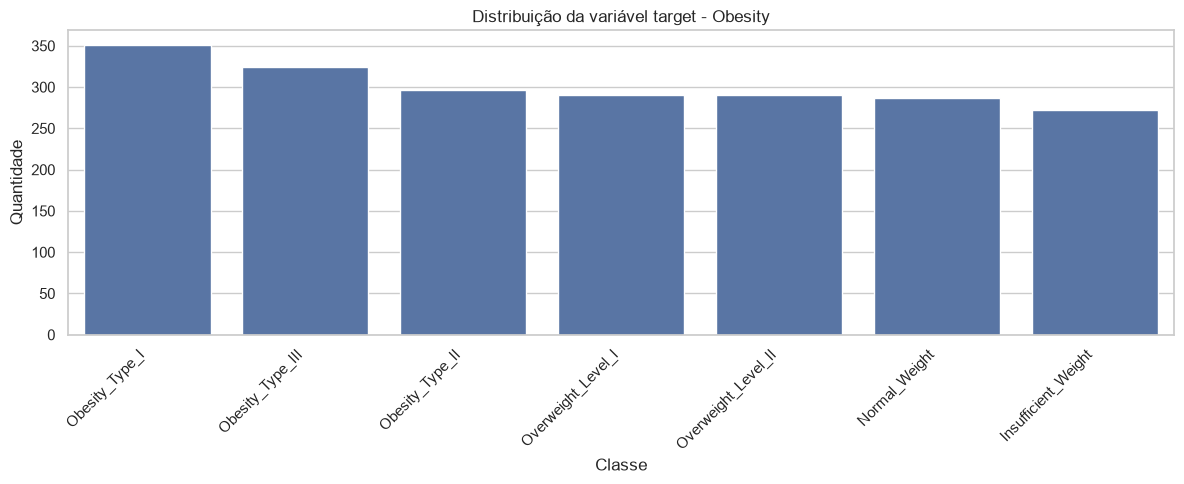

In [31]:
# ============================================================
# 8. DISTRIBUIÇÃO DA TARGET
# ============================================================

target_counts = df_eda[target].value_counts()
target_perc = df_eda[target].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({
    "qtd": target_counts,
    "perc": target_perc
})

display(target_dist)

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_eda,
    x=target,
    order=target_counts.index
)
plt.title("Distribuição da variável target - Obesity")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()